In [97]:
import numpy as np
from sklearn.linear_model import OrthogonalMatchingPursuit
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.linalg import toeplitz

In [2]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'

In [3]:
u = np.genfromtxt("contrast.txt")
u

array([[0.      , 0.      , 0.      , ..., 0.168482, 0.168466, 0.168449],
       [0.      , 0.      , 0.      , ..., 0.168535, 0.168519, 0.168502],
       [0.      , 0.      , 0.      , ..., 0.168588, 0.168571, 0.168555],
       ...,
       [0.      , 0.      , 0.      , ..., 0.189189, 0.189185, 0.18918 ],
       [0.      , 0.      , 0.      , ..., 0.189203, 0.189199, 0.189195],
       [0.      , 0.      , 0.      , ..., 0.189211, 0.189206, 0.189202]])

In [4]:
u.shape

(1001, 30001)

In [6]:
input = u[0,:]
output = u[-1, :]

In [7]:
input.size

30001

In [8]:
t = np.linspace(0, 10, input.size)

In [82]:
syst = 0.32
arr_end_syst = np.arange(0, 10) + syst
arr_end_syst

array([0.32, 1.32, 2.32, 3.32, 4.32, 5.32, 6.32, 7.32, 8.32, 9.32])

In [83]:
input_CT_MPI = np.zeros_like(arr_end_syst)
output_CT_MPI = np.zeros_like(arr_end_syst)
for i, value in enumerate(arr_end_syst):
    input_CT_MPI[i] = input[np.isclose(t, value)]
    output_CT_MPI[i] = output[np.isclose(t, value)]

print(input_CT_MPI)

[0.021815 0.22514  0.421827 0.523947 0.538061 0.494926 0.423646 0.344702
 0.270098 0.20557 ]


/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/1285850796.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_CT_MPI[i] = input[np.isclose(t, value)]
/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/1285850796.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output_CT_MPI[i] = output[np.isclose(t, value)]


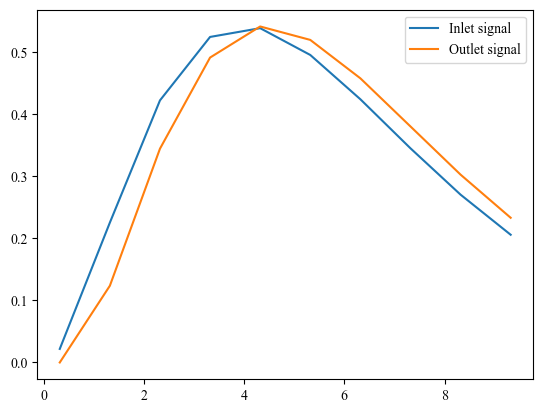

In [84]:
plt.plot(arr_end_syst, input_CT_MPI, label="Inlet signal")
plt.plot(arr_end_syst, output_CT_MPI, label="Outlet signal")
plt.legend()
plt.show()

In [85]:
interp_length = 1000
interp_input = interp1d(arr_end_syst, input_CT_MPI, kind='cubic')
interp_output = interp1d(arr_end_syst, output_CT_MPI, kind='cubic')
time_points_sampled = np.linspace(arr_end_syst[0], arr_end_syst[-1], interp_length)
input_function = interp_input(time_points_sampled)
output_function = interp_output(time_points_sampled)


0.0
inf


/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/82274646.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  v_estimated_omp = 10 / estimated_delay


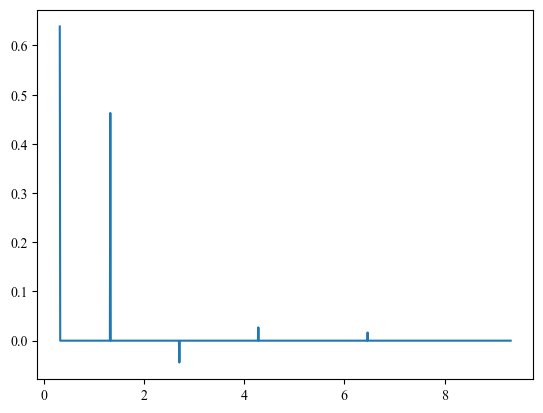

In [87]:
# creating the A matrix based on the input function using toeplitz structure
A = toeplitz(input_function, np.zeros(len(input_function)))

# Using Orthogonal Matching Pursuit (OMP) for recovering the actual input and output functions assuming sparsity
omp = OrthogonalMatchingPursuit(n_nonzero_coefs=5)
omp.fit(A, output_function)
x_sol_omp = omp.coef_
plt.figure()
plt.plot(time_points_sampled, x_sol_omp)
# Estimating velocity from the system response
delay_indices = np.argmax(x_sol_omp)  # index of maximum response
estimated_delay = time_points_sampled[delay_indices] - arr_end_syst[0]
print(estimated_delay)
v_estimated_omp = 10 / estimated_delay

print(v_estimated_omp)

In [88]:
arr_multiphase = np.array([1., 3.32, 4., 5.9, 6.8])
input_CT_MPI = np.zeros_like(arr_multiphase)
output_CT_MPI = np.zeros_like(arr_multiphase)
time_multiphase = np.zeros_like(arr_multiphase)
for i, value in enumerate(arr_multiphase):
    input_CT_MPI[i] = input[np.isclose(t, value)]
    output_CT_MPI[i] = output[np.isclose(t, value)]
    time_multiphase[i] = t[np.isclose(t, value)]

print(input_CT_MPI)
print(output_CT_MPI)
print(time_multiphase)

[0.151633 0.523947 0.541341 0.455486 0.385795]
[0.068092 0.490758 0.535785 0.478462 0.407573]
[1.   3.32 4.   5.9  6.8 ]


/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/896556952.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_CT_MPI[i] = input[np.isclose(t, value)]
/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/896556952.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output_CT_MPI[i] = output[np.isclose(t, value)]
/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/896556952.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.2

0.3831831831831831
26.097178683385586


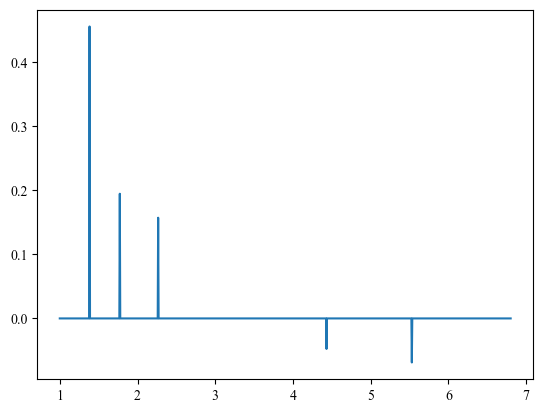

In [89]:
interp_length = 1000
interp_input = interp1d(arr_multiphase, input_CT_MPI, kind='cubic')
interp_output = interp1d(arr_multiphase, output_CT_MPI, kind='cubic')
time_points_sampled = np.linspace(time_multiphase[0], time_multiphase[-1], interp_length)
input_function = interp_input(time_points_sampled)
output_function = interp_output(time_points_sampled)


# creating the A matrix based on the input function using toeplitz structure
A = toeplitz(input_function, np.zeros(len(input_function)))

# Using Orthogonal Matching Pursuit (OMP) for recovering the actual input and output functions assuming sparsity
omp = OrthogonalMatchingPursuit(n_nonzero_coefs=5)
omp.fit(A, output_function)
x_sol_omp = omp.coef_
plt.figure()
plt.plot(time_points_sampled, x_sol_omp)
# Estimating velocity from the system response
indices = np.argsort(x_sol_omp)  # index of maximum response
delay_indices = indices[-1]
estimated_delay = time_points_sampled[delay_indices] - time_multiphase[0]
print(estimated_delay)
v_estimated_omp = 10 / estimated_delay

print(v_estimated_omp)

### Recursive convolution method

In [ ]:
v_initial = 10

delay = 10. / v_initial
delay

1.0

In [99]:
transluminal_att= u[:,np.isclose(t, 4)].T
TAG,_,_,_,_ = linregress(np.linspace(0,10,transluminal_att.size), transluminal_att)
transluminal_att.size

1001

In [100]:
length_array = np.linspace(0,10,100)
delay_array = length_array/v_initial


In [96]:
arr1 = np.array([1, 2, 3, 4, 5, 6])
np.roll(arr1, shift=-2)

array([3, 4, 5, 6, 1, 2])

In [103]:
full_array = np.zeros((length_array.size,output.size))
for i, delay in enumerate(delay_array):
    shift = np.argmax(np.isclose(t, 4)) - np.argmax(np.isclose(t - delay,4))
    full_array[i, :] = np.roll(output, shift=shift)


estimated_TA = full_array[:, np.isclose(t, 4)].T
estimated_TAG,_,_,_,_ = linregress(length_array,estimated_TA)


In [104]:
print(TAG)

-0.0005793221927772831


In [105]:
print(estimated_TAG)

-0.00019819520792079134


In [108]:
factor = TAG/estimated_TAG
v_new = v_initial * factor
v_new

np.float64(29.229878908515744)

In [137]:
v_initial = 10
transluminal_att= u[:,np.isclose(t, 4)].T
TAG,_,_,_,_ = linregress(np.linspace(0,10,transluminal_att.size), transluminal_att)
length_array = np.linspace(0,10,100)

Error = 1
while np.abs(Error) >= 0.01:
    delay_array = length_array/v_initial
    full_array = np.zeros((length_array.size,output.size))
    for i, delay in enumerate(delay_array):
        shift = np.argmax(np.isclose(t, 4)) - np.argmax(np.isclose(t - delay,4))
        full_array[i, :] = np.roll(output, shift=-1*shift)


    estimated_TA = full_array[:, np.isclose(t, 4)].T
    estimated_TAG,_,_,_,_ = linregress(length_array,estimated_TA[::-1])
    factor = estimated_TAG/TAG
    v_new = v_initial * factor
    Error = np.sqrt(np.sqrt(v_new ** 2 - v_initial ** 2))
    v_initial = v_new

    print(v_initial)

34.55440019503095
-48.4808093003919
-71.70171018309645
-132.0225951890876
-169.04248969369206
-51.509047391823245


/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/1864597228.py:19: RuntimeWarning: invalid value encountered in sqrt
  Error = np.sqrt(np.sqrt(v_new ** 2 - v_initial ** 2))


In [141]:
# Parameters
v_initial = 15.0
length_array = np.linspace(0, 10, 100)
dt = t[1] - t[0]
target_time_idx = np.argmin(np.abs(t - 4.0)) # Index where t is closest to 4

# The actual measured TAG (target)
transluminal_att = u[:, target_time_idx].T 
TAG, _, _, _, _ = linregress(np.linspace(0, 10, transluminal_att.size), transluminal_att)

error = 1.0
tolerance = 0.01
max_iter = 100
iteration = 0

while np.abs(error) >= tolerance and iteration < max_iter:
    # 1. Create the spatial-temporal array based on current velocity
    # We shift the 'output' (temporal profile) by the delay to each point z
    full_array = np.zeros((len(length_array), len(t)))
    
    for i, z in enumerate(length_array):
        delay = z / v_initial
        shift = int(round(delay / dt))
        # Roll the temporal profile 'output' for this specific z-location
        full_array[i, :] = np.roll(output, shift)

    # 2. Extract the spatial gradient at the specific time t=4
    estimated_TA = full_array[:, target_time_idx]
    estimated_TAG, _, _, _, _ = linregress(length_array, estimated_TA)

    # 3. Update Velocity
    # If TAG is negative (usual), and estimated_TAG is more negative than target, 
    # the factor will guide the direction.
    factor = estimated_TAG / TAG
    v_new = v_initial * factor
    
    error = v_new - v_initial
    v_initial = v_new
    
    iteration += 1
    print(f"Iter {iteration}: v = {v_initial:.4f}, Error = {error:.4f}")

Iter 1: v = 98.7360, Error = 83.7360
Iter 2: v = 17.2508, Error = -81.4853
Iter 3: v = 73.6796, Error = 56.4289
Iter 4: v = 19.2099, Error = -54.4697
Iter 5: v = 61.7920, Error = 42.5821
Iter 6: v = 20.7275, Error = -41.0645
Iter 7: v = 52.6508, Error = 31.9233
Iter 8: v = 22.3987, Error = -30.2522
Iter 9: v = 43.4240, Error = 21.0253
Iter 10: v = 24.8668, Error = -18.5572
Iter 11: v = 37.2570, Error = 12.3902
Iter 12: v = 27.3007, Error = -9.9563
Iter 13: v = 34.2195, Error = 6.9188
Iter 14: v = 28.8784, Error = -5.3411
Iter 15: v = 32.6873, Error = 3.8090
Iter 16: v = 29.8118, Error = -2.8756
Iter 17: v = 31.8956, Error = 2.0838
Iter 18: v = 30.3439, Error = -1.5517
Iter 19: v = 31.4737, Error = 1.1297
Iter 20: v = 30.6308, Error = -0.8429
Iter 21: v = 31.2494, Error = 0.6186
Iter 22: v = 30.7900, Error = -0.4594
Iter 23: v = 31.1260, Error = 0.3359
Iter 24: v = 30.8781, Error = -0.2479
Iter 25: v = 31.0614, Error = 0.1834
Iter 26: v = 30.9255, Error = -0.1360
Iter 27: v = 31.0227, E

In [150]:

n_elements = 1000
L = 10.0
Tfinal = 10.0
target_CFL = 1.0

mean_velocity = 30 # cm/s

# Define time stepping of implicit Euler method (=dt)
h = L / n_elements
dt = target_CFL * h / mean_velocity
n_steps = mean_velocity * 1000 # for this specific length and duration #int(np.ceil(Tfinal / dt))


# Input Velocity (Unsteady)
heart_cycle = 1.0 # seconds = 60 BPM
num_points = mean_velocity * 100
t = np.linspace(0, heart_cycle, num_points, endpoint=True)

systole_end = 0.32   # systole ~32% of cycle

flow = np.full_like(t, 0.25 * mean_velocity)   # baseline

syst = t < systole_end
flow[syst] += 0.85 * mean_velocity * np.sin(np.pi * t[syst] / systole_end)**2

diast = t >= systole_end
diast_duration = heart_cycle - systole_end

x = np.pi * (t[diast] - systole_end) / diast_duration
k = 0.8
flow[diast] += mean_velocity * 1/np.arcsin(k)*np.arctan(k*np.sin(x)/(1 - k*np.cos(x)))


# Force exact mean 
flow = flow * (mean_velocity / np.mean(flow))


# Imaging duration: 10 heart cycle
final_velocity = np.tile(flow, 10) # reps = Tfinal / heart_cycle duration


A=200.0; Ts=0.0; alpha=2.0; b=2.0
t = np.linspace(0, Tfinal, n_steps)
inlet_contrast = np.zeros_like(t)

inlet_contrast += A * pow(t - Ts, alpha) / pow(b, alpha) * np.exp( -(t - Ts)/b ) * (t >= Ts)



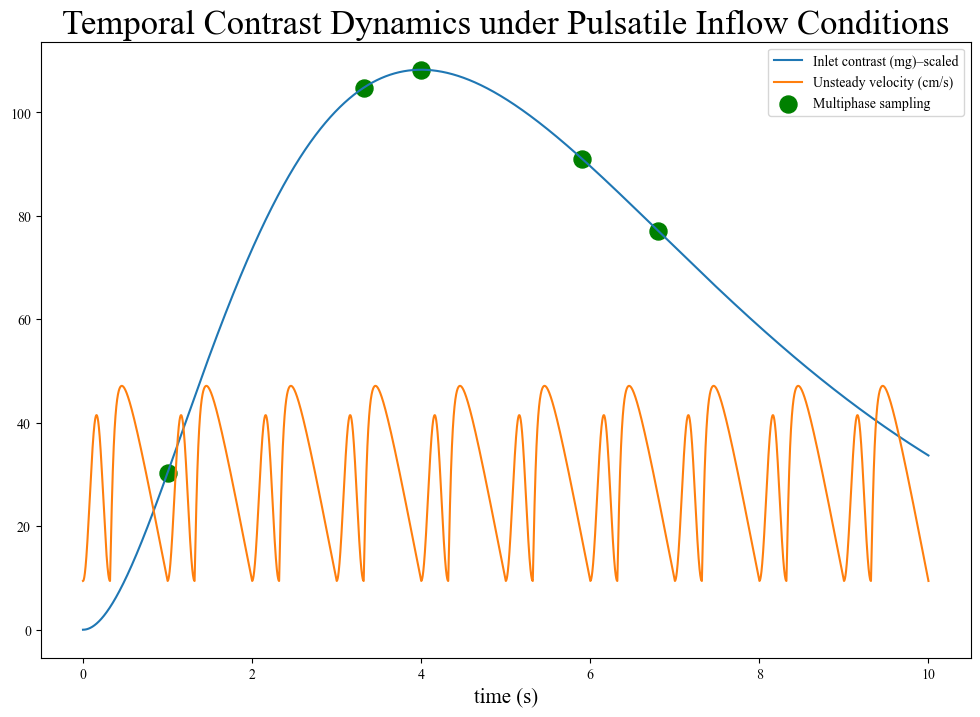

In [163]:

plt.figure(figsize=(12, 8))
plt.plot(t, inlet_contrast, label='Inlet contrast (mg)–scaled')
plt.plot(t, final_velocity, label='Unsteady velocity (cm/s)')
plt.scatter(time_multiphase, input_CT_MPI*200, color = 'green', label="Multiphase sampling", s=150)
plt.title("Temporal Contrast Dynamics under Pulsatile Inflow Conditions", size=25)
plt.xlabel("time (s)", size=15)

plt.legend()
plt.show()